In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st


In [95]:
df = pd.read_csv('spotify.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  str    
 1   album_name        113999 non-null  str    
 2   track_name        113999 non-null  str    
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             114000 non-nu

In [96]:
df.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [97]:
variables = ['danceability', 'acousticness', 'explicit', 'track_genre']
df_rawvar = df[variables]
df_var = df_rawvar.dropna().drop_duplicates()
df_var.info()
genre = ['pop', 'rock', 'hip-hop', 'classical', 'jazz']
df_var = df_var[df['track_genre'].isin(genre)]
df_var


<class 'pandas.DataFrame'>
Index: 102571 entries, 0 to 113999
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   danceability  102571 non-null  float64
 1   acousticness  102571 non-null  float64
 2   explicit      102571 non-null  bool   
 3   track_genre   102571 non-null  str    
dtypes: bool(1), float64(2), str(1)
memory usage: 3.2 MB


C:\Users\salva\AppData\Local\Temp\ipykernel_23000\1550420487.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_var = df_var[df['track_genre'].isin(genre)]


,danceability,acousticness,explicit,track_genre
16000,0.643,0.5930,False,classical
16001,0.484,0.3650,False,classical
16002,0.608,0.5810,False,classical
16003,0.695,0.5960,False,classical
16004,0.583,0.5810,False,classical
...,...,...,...,...
91985,0.547,0.0393,False,rock
91986,0.459,0.2960,False,rock
91987,0.440,0.0956,False,rock
91988,0.552,0.4450,False,rock


In [98]:
df_samplevar = df_var.sample(n=1000, replace=True, random_state=42)
df_samplevar = df_samplevar.reset_index(drop=True)
df_var = df_var.reset_index(drop=True)

In [99]:
df_samplevar

,danceability,acousticness,explicit,track_genre
0,0.717,0.708000,False,rock
1,0.689,0.369000,False,hip-hop
2,0.609,0.357000,False,hip-hop
3,0.540,0.046600,False,hip-hop
4,0.655,0.476000,False,hip-hop
...,...,...,...,...
995,0.467,0.000187,False,rock
996,0.664,0.031600,False,jazz
997,0.387,0.955000,False,classical
998,0.579,0.020200,False,rock


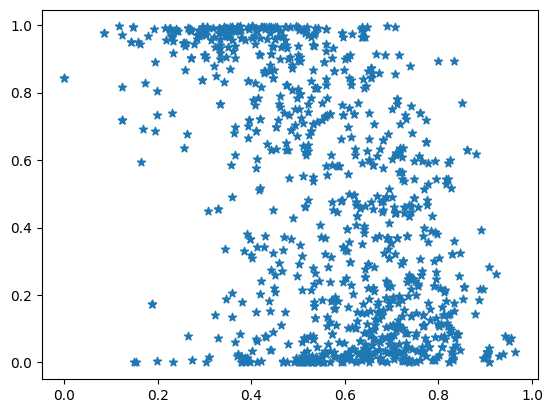

In [100]:
plt.scatter(df_samplevar['danceability'],df_samplevar['acousticness'],marker='*')
plt.show()

In [101]:
er = st.linregress(df_samplevar['danceability'],df_samplevar['acousticness'])
er

LinregressResult(slope=np.float64(-1.0679953350368996), intercept=np.float64(1.0706183872635655), rvalue=np.float64(-0.521022548784872), pvalue=np.float64(1.1147088836833166e-70), stderr=np.float64(0.05538254722812142), intercept_stderr=np.float64(0.03305455949992995))

In [102]:
n = len(df_samplevar)
x = df_samplevar.danceability
y = df_samplevar.acousticness
b = er.slope
a = er.intercept
hy = a + b*x
e = y-hy
sse = np.sum(e**2)
hs2 = (sse)/(n)

In [103]:
hs2

np.float64(0.09750933464891161)

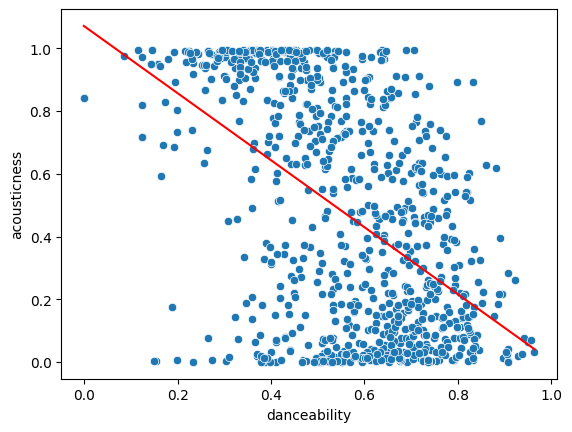

In [104]:
fit = [b,a]
poly = np.poly1d(fit)
rang = max(x)-min(x)
lb = min(x) - (rang/1000)
lu = max(x) + (rang/1000)
z = [lb,lu]
sns.scatterplot(data=df_samplevar, x=df_samplevar['danceability'],y=df_samplevar['acousticness'], markers='*')
plt.plot(z,poly(z),'r-')

In [105]:
R2 = (er.rvalue)**2
p = er.pvalue
p, R2

(np.float64(1.1147088836833166e-70), np.float64(0.2714644963422843))

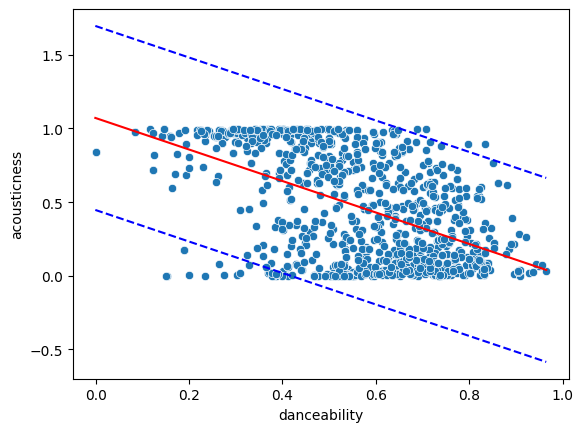

In [106]:
sns.scatterplot(data=df_samplevar, x=x,y=y,markers='x')
plt.plot(z,poly(z),'r-')
plt.plot(z,poly(z) + 2*np.sqrt(hs2), 'b--')
plt.plot(z,poly(z) - 2*np.sqrt(hs2), 'b--')

In [107]:
x0 = np.linspace(lb,lu,1000)
hy0 = poly(x0)
v0 = (np.var(x)+(x0-np.mean(x))**2) / (n*np.var(x))
alpha = 0.05
t = st.t.ppf(1-(alpha/2),n)

In [108]:
ss_x = n*np.var(x)
v0 = ((1/n) + ((x0-np.mean(x))**2)) / ss_x


In [109]:
eps = t*np.sqrt(v0*hs2)
mean_lo = hy0-eps
mean_hi = hy0 + eps

In [110]:
eps2 = t*np.sqrt(hs2*(1+v0))
outp_lo = hy0-eps2
outp_hi = hy0+eps2

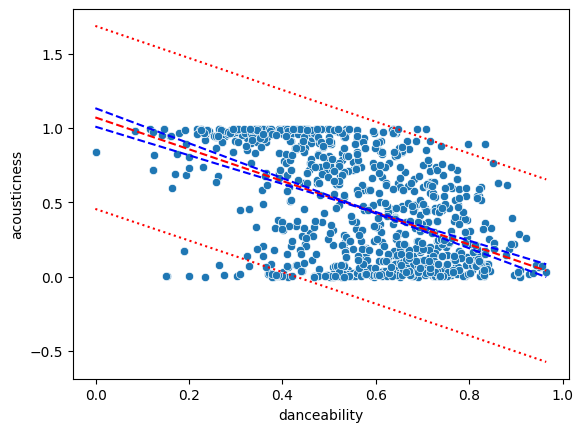

In [111]:
sns.scatterplot(data=df_samplevar,x=x,y=y,markers='*')
plt.plot(x0,poly(x0),'r--')
plt.plot(x0, mean_lo, 'b--')
plt.plot(x0, mean_hi , 'b--')
plt.plot(x0, outp_lo, 'r:')
plt.plot(x0, outp_hi, 'r:')

In [124]:
z = x**3
er2 = st.linregress(z,y)
er2

LinregressResult(slope=np.float64(-0.9879886874767895), intercept=np.float64(0.6966221646160753), rvalue=np.float64(-0.484658338366422), pvalue=np.float64(4.927116735602724e-60), stderr=np.float64(0.05644323536748107), intercept_stderr=np.float64(0.01678441199059581))

<Axes: xlabel='danceability', ylabel='acousticness'>

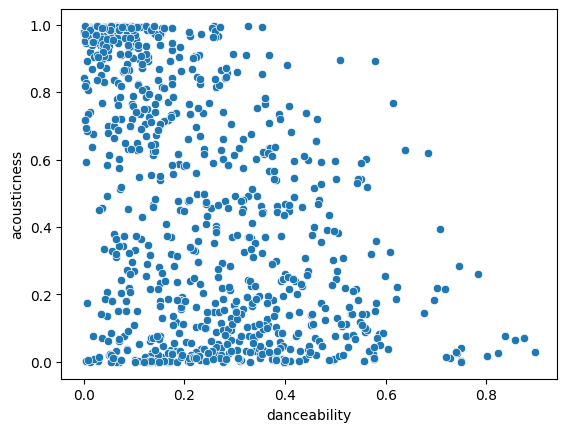

In [125]:
z
sns.scatterplot(data=df_samplevar,x=z,y=y)

In [114]:
c = er2.intercept
d = er2.slope
hy2 = c + d*z
e2 = y-hy2
sse2 = np.sum(e**2)
hs22 = (sse2)/(n-1)
hs22


np.float64(0.09760694159050211)

In [115]:
fit2 = [d,c]
poly2 = np.poly1d(fit)
rang2 = max(z)-min(z)
lb = min(x) -(rang2/1000)
lu = max(x) +(rang/20)
z = [lb,lu]
sns.scatterplot(data=df_samplevar,x=z,y=y,markers='*')
sns.scatterplot(x=z,y=y)

ValueError: Length of list vectors must match length of `data` when both are used, but `data` has length 1000 and the vector passed to `x` has length 2.